In [131]:
import cv2  # OpenCV library for image processing
import matplotlib.pyplot as plt  # For plotting images using matplotlib

# Load the original image from file
img = cv2.imread('balls.jpg')  # Reads the image in BGR format (default)

# Convert the BGR image to grayscale (simplifies further processing)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # cv2.COLOR_BGR2GRAY converts 3-channel color to 1-channel grayscale

# Apply Gaussian Blur to reduce noise before thresholding
# (15,15) is the kernel size — must be odd numbers. 0 is the sigma (auto-calculated)
blur = cv2.GaussianBlur(gray, (15, 15), 0)

# Apply Otsu's thresholding with inverse binary
# 0 = ignore manual threshold value (Otsu will choose automatically)
# 255 = max pixel value
# THRESH_BINARY_INV = white objects on black background
# THRESH_OTSU = automatically finds optimal threshold from image histogram
_, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Create a custom elliptical kernel for morphological operation
# (20, 60) = width and height of the kernel (in pixels)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 60))

# Apply a morphological operation to clean the thresholded image
# BUT this line has a mistake — MORPH_CROSS is not a valid operation here
# You likely meant MORPH_CLOSE
# Should be:
closed = cv2.morphologyEx(otsu, cv2.MORPH_CLOSE, kernel)

# Now apply opening to remove remaining small dots (requires defining 'opened')
opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)

# Find external contours in the binary image (white objects on black background)
# cv2.RETR_EXTERNAL: retrieves only outer contours
# cv2.CHAIN_APPROX_SIMPLE: compresses horizontal, vertical, and diagonal segments
contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter contours based on area — remove small ones
# Only keep contours with area > 500 pixels
filtered = [cnt for cnt in contours if cv2.contourArea(cnt) > 500]

# Make a copy of the original image to draw contours on
img_copy = img.copy()

# Draw all filtered contours on the copied image
# -1 means draw all contours
# (0, 255, 0) = color (green) in BGR
# 2 = thickness of contour line
cv2.drawContours(img_copy, filtered, -1, (0, 255, 0), 2)


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

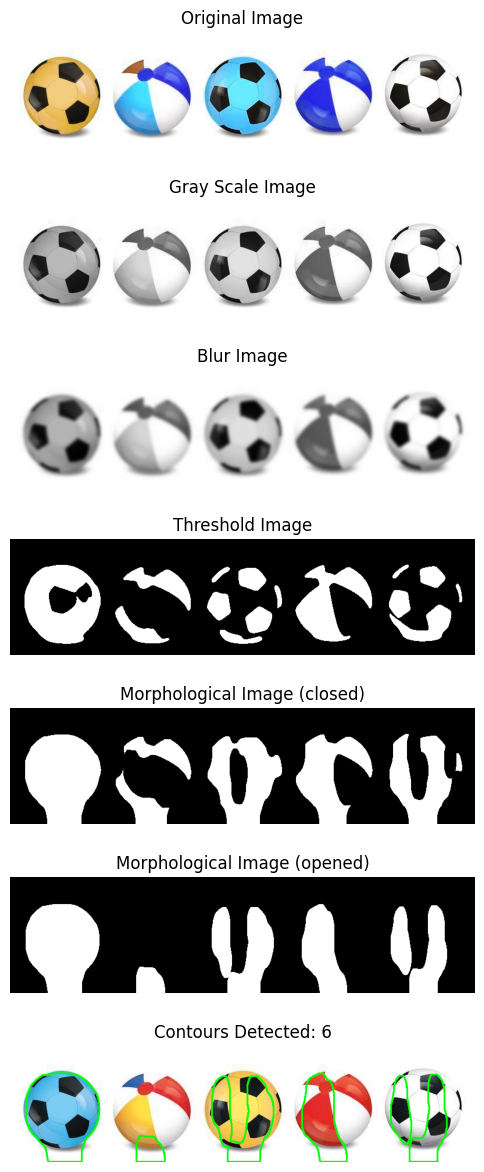

<Figure size 640x480 with 0 Axes>

In [132]:
plt.figure(figsize=(6, 15))  # Width x Height in inches

plt.subplot(7, 1, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(7, 1, 2)
plt.imshow(gray, cmap='gray')
plt.title("Gray Scale Image")
plt.axis('off')

plt.subplot(7, 1, 3)
plt.imshow(blur, cmap='gray')
plt.title("Blur Image")
plt.axis('off')

plt.subplot(7, 1, 4)
plt.imshow(otsu, cmap='gray')
plt.title("Threshold Image")
plt.axis('off')

plt.subplot(7, 1, 5)
plt.imshow(closed, cmap='gray')
plt.title("Morphological Image (closed)")
plt.axis('off')

plt.subplot(7, 1, 6)
plt.imshow(opened, cmap='gray')
plt.title("Morphological Image (opened)")
plt.axis('off')

plt.subplot(7, 1, 7)
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title(f"Contours Detected: {len(filtered)}")
plt.axis('off')
plt.show()

plt.tight_layout()
plt.show()